In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [16]:
def find_plate(img_path):
    img = cv.imread(img_path)

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    _, binary = cv.threshold(gray, 103, 255, cv.THRESH_BINARY)
    
    contours, _ = cv.findContours(binary, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
    
    plate_contour = None
    for cnt in contours:
        area = cv.contourArea(cnt)
        if area < 1500 or area > 3400:  
            continue
            
        x, y, w, h = cv.boundingRect(cnt)
        aspect_ratio = w / h

        if w * h > 5000:
            continue

        if 2.5 < aspect_ratio < 6.0:
            if plate_contour is None or area > cv.contourArea(plate_contour):
                plate_contour = cnt
    
    
    if plate_contour is None:
        return None

    rect = cv.minAreaRect(plate_contour)
    angle = rect[2]
    box = cv.boxPoints(rect)
    box = np.intp(box)
    
    if angle > 45:
        angle = angle - 90
    elif angle < -45:
        angle = 90 + angle

    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv.warpAffine(img, M, (w, h), flags=cv.INTER_CUBIC)

    box = cv.boxPoints(rect)
    box_rotated = cv.transform(np.array([box]), M)[0]
    x, y = box_rotated.min(axis=0).astype(int)
    x2, y2 = box_rotated.max(axis=0).astype(int)
    
    cropped_plate = rotated[y:y2, x:x2]

    return cropped_plate


In [17]:
def load_templates():
    letters = ['A', 'B', 'C', 'E', 'H', 'K', 'M', 'O', 'P', 'T', 'X', 'Y']
    digits = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
    
    templates = {}
    
    for letter in letters:
        template_path = f'../plate_symb/letters/{letter}.png'
        template = cv.imread(template_path, 0)        
        if template is not None:
            templates[letter] = template
    
    for digit in digits:
        template_path = f'../plate_symb/digits/{digit}.png'
        template = cv.imread(template_path, 0)
        if template is not None:
            templates[digit] = template
            
    return templates

In [18]:
def recognize_char(char_img, templates, char_type):
    best_match = None
    best_score = -1
    
    if char_type == 'letter':
        available_templates = {k: v for k, v in templates.items() if k in ['A', 'B', 'C', 'E', 'H', 'K', 'M', 'O', 'P', 'T', 'X', 'Y']}
    else:
        available_templates = {k: v for k, v in templates.items() if k in ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']}
    
    for char_name, template in available_templates.items():
        scaled_template = cv.resize(template, (char_img.shape[1], char_img.shape[0]))

        result = cv.matchTemplate(char_img, scaled_template, cv.TM_CCOEFF_NORMED)
        _, max_val, _, _ = cv.minMaxLoc(result)
        
        if max_val > best_score:
            best_score = max_val
            best_match = char_name
    
    return best_match 

In [21]:
def extract_text(cropped_plate, templates):
    target_height = 100
    aspect_ratio = cropped_plate.shape[1] / cropped_plate.shape[0]
    target_width = int(target_height * aspect_ratio)
    normalized_plate = cv.resize(cropped_plate, (target_width, target_height))

    char_regions = [
        (int(0.07 * target_width), int(0.2 * target_height), int(0.12 * target_width), int(0.7 * target_height)),  # 1 буква
        (int(0.19 * target_width), int(0.08 * target_height), int(0.11 * target_width), int(0.82 * target_height)), # 2 цифра
        (int(0.3 * target_width), int(0.1 * target_height), int(0.12 * target_width), int(0.82 * target_height)), # 3 цифра
        (int(0.41 * target_width), int(0.1 * target_height), int(0.11 * target_width), int(0.8 * target_height)), # 4 цифра
        (int(0.53 * target_width), int(0.2 * target_height), int(0.11 * target_width), int(0.7 * target_height)), # 5 буква
        (int(0.63 * target_width), int(0.2 * target_height), int(0.12 * target_width), int(0.7 * target_height)), # 6 буква
        (int(0.79 * target_width), int(0.04 * target_height), int(0.08 * target_width), int(0.7 * target_height)), # 7 цифра
        (int(0.87 * target_width), int(0.04 * target_height), int(0.08 * target_width), int(0.7 * target_height))  # 8 цифра
    ]
    
    characters = []
    for i, (x, y, w, h) in enumerate(char_regions):

        x = max(0, x)
        y = max(0, y)
        w = min(w, normalized_plate.shape[1] - x)
        h = min(h, normalized_plate.shape[0] - y)
        
        if w > 0 and h > 0:
            char_img = normalized_plate[y:y+h, x:x+w]

            char_gray = cv.cvtColor(char_img, cv.COLOR_BGR2GRAY)
            _, char_binary = cv.threshold(char_gray, 100, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
            characters.append(char_binary)

    plate_text = ""
    
    recognized_char1 = recognize_char(characters[0], templates, 'letter')
    recognized_char2 = recognize_char(characters[1], templates, 'digit')
    recognized_char3 = recognize_char(characters[2], templates, 'digit')
    recognized_char4 = recognize_char(characters[3], templates, 'digit')
    recognized_char5 = recognize_char(characters[4], templates, 'letter')
    recognized_char6 = recognize_char(characters[5], templates, 'letter')
    recognized_char7 = recognize_char(characters[6], templates, 'digit')
    recognized_char8 = recognize_char(characters[7], templates, 'digit')
    plate_text = recognized_char1 + recognized_char2 + recognized_char3 + recognized_char4 + recognized_char5 + recognized_char6 + recognized_char7 + recognized_char8
    
    return plate_text

In [14]:
def map_letters(plate):
    letters = {"Y":"У"}
    res = []
    for s in plate:
        if s in letters:
            res.append(letters[s])
        else:
            res.append(s)

    return "".join(res)

In [7]:
templates = load_templates()

A023TУ97


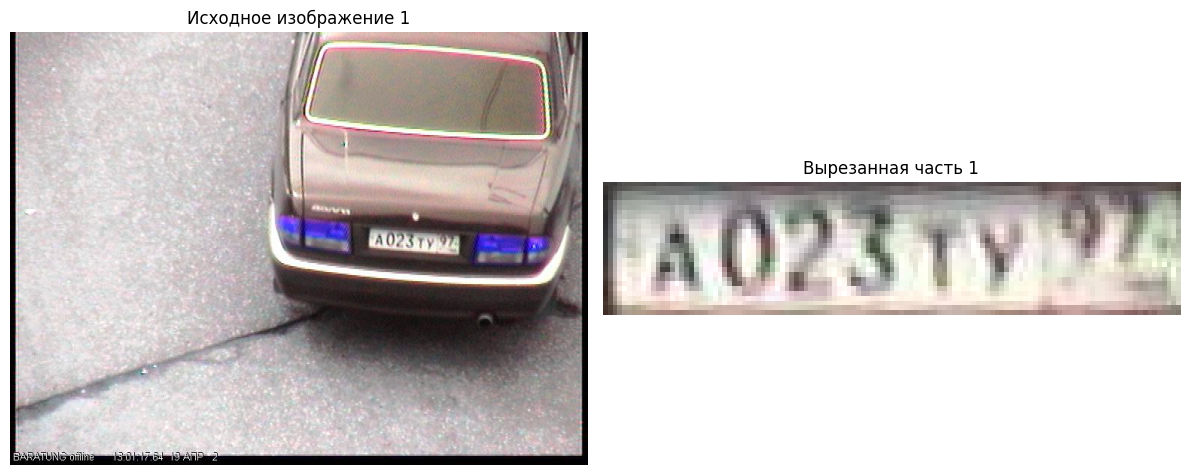

K263CO97


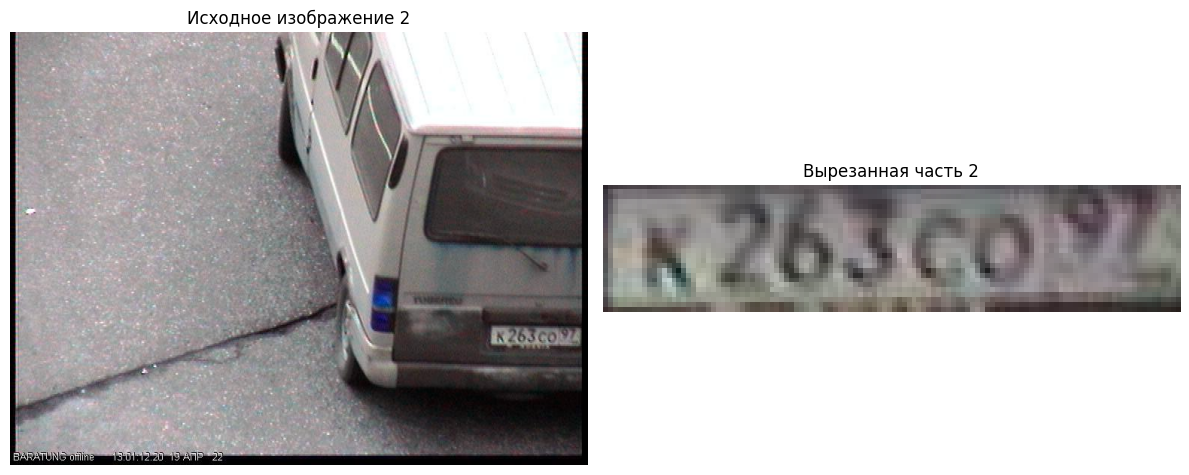

T829MK97


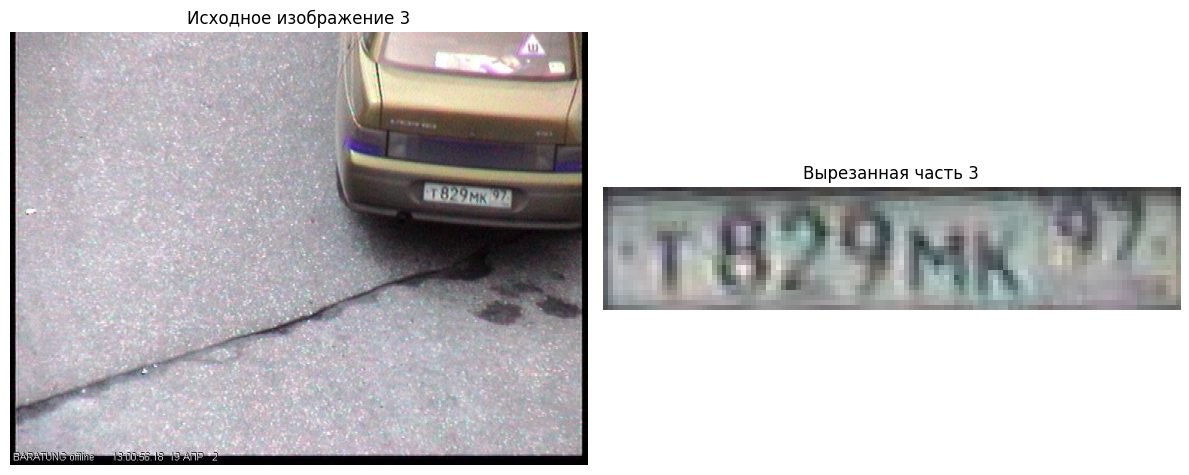

M136УE97


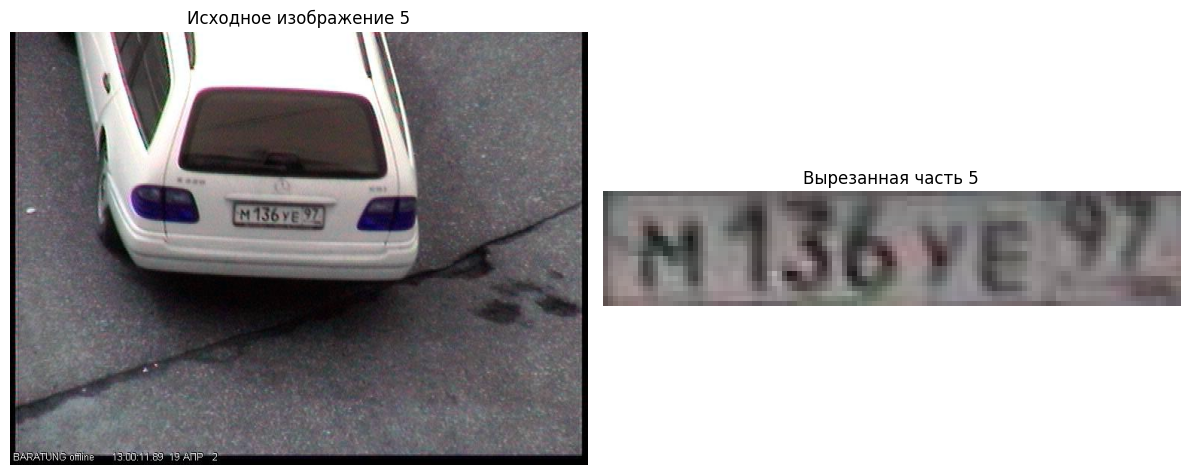

O571KT99


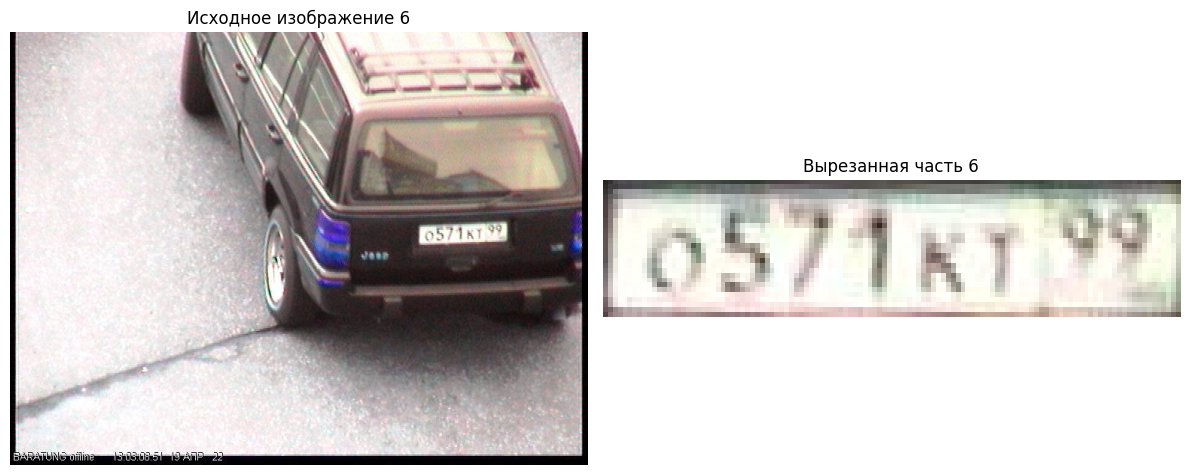

K760PA97


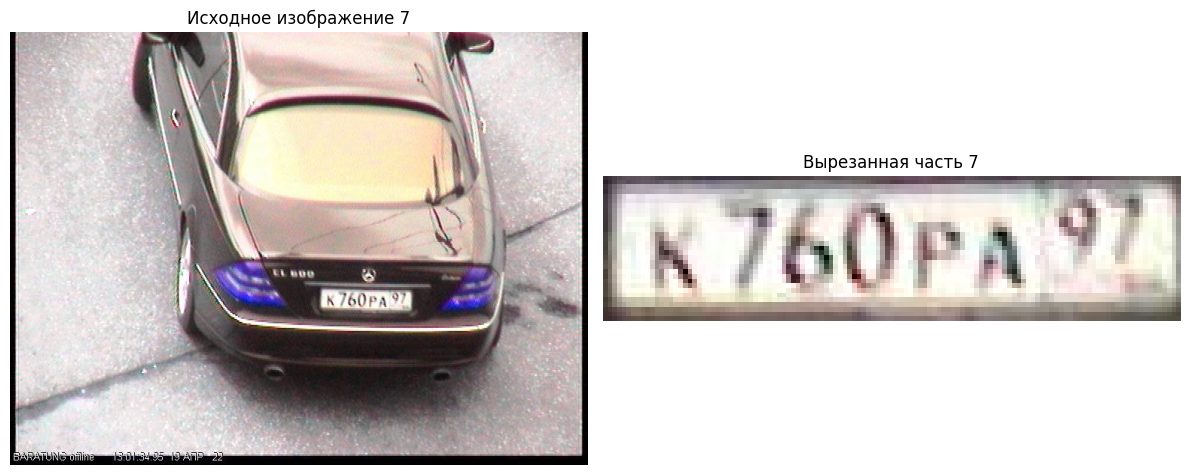

In [22]:
#вырезать побольше цифры, пройтись несколько раз по кропнутому изображению чтобы определить 

img_count = 8

for i in range(1, img_count + 1):
    img_path = f"../car_plates_img/car_p_{i}.jpg"
    img = cv.imread(img_path)
    cropped_img = find_plate(img_path)
    if(cropped_img is None):
        continue

    plate_number = extract_text(cropped_img, templates)
    print(map_letters(plate_number))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    ax1.imshow(img)
    ax1.set_title(f'Исходное изображение {i}')
    ax1.axis('off')

    ax2.imshow(cropped_img)
    ax2.set_title(f'Вырезанная часть {i}')
    ax2.axis('off')

    ax1.set_aspect('equal')
    ax2.set_aspect('equal')

    plt.tight_layout()
    plt.show()
